# RNA para Regresión con Diabetes

Este notebook presenta la implementación de una Red Neuronal Artificial (RNA) utilizando Keras para resolver un problema de regresión sobre el conjunto de datos de diabetes.

Además del entrenamiento del modelo base, se realizarán distintos experimentos modificando hiperparámetros como la cantidad de capas, el número de neuronas, el número de épocas y el tamaño de lote (*batch size*), con el objetivo de analizar su efecto en el rendimiento del modelo.

Finalmente, se aplicará una técnica de búsqueda automática de hiperparámetros mediante **RandomizedSearchCV**, para identificar una configuración optimizada y comparar sus resultados con el modelo inicial.


## 1. Importar librerías


In [13]:
# Librerías base
import numpy as np
import matplotlib.pyplot as plt

# Dataset y preprocesamiento
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep Learning
from tensorflow import keras
from tensorflow.keras import layers

# Wrapper para usar Keras con sklearn
from scikeras.wrappers import KerasRegressor


## 2. Cargar dataset
El objetivo es predecir una medida cuantitativa de progresión de diabetes.


In [14]:
data = load_diabetes()

X = data.data
y = data.target

# Dimensiones
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

# Primeros valores
print("Primeros 5 valores de y:", y[:5])

# Información adicional
print("\nNombre de variables:", data.feature_names)


Forma de X: (442, 10)
Forma de y: (442,)
Primeros 5 valores de y: [151.  75. 141. 206. 135.]

Nombre de variables: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## 3. Separar entrenamiento y validación


In [15]:
# Primero train + test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Luego train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)


## 4. Estandarización de variables

Se aplica una estandarización de los datos utilizando `StandardScaler`, con el objetivo de mejorar el desempeño del modelo.

El escalador se ajusta únicamente sobre el conjunto de entrenamiento y luego se aplica al conjunto de validación y prueba, evitando así el uso de información futura (*data leakage*).


In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


## 5. Creación de la red neuronal

Se define una función que permite construir la red neuronal de forma flexible, facilitando la experimentación con distintos hiperparámetros como:

- Número de capas ocultas
- Número de neuronas por capa
- Tasa de aprendizaje

Esto permite analizar cómo estos parámetros afectan el rendimiento del modelo.


In [17]:
def build_model(n_hidden=2, n_neurons=128):
    
    model = keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))
    
    # Capas ocultas
    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation="relu"))
    
    # Capa de salida
    model.add(layers.Dense(1))
    
    return model

model = build_model()

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
    
  


## 6. Compilar modelo


In [18]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


## 7. Entrenamiento del modelo base

Se entrena el modelo utilizando los datos de entrenamiento, y se evalúa su desempeño en el conjunto de validación para monitorear el aprendizaje y detectar posibles problemas de sobreajuste.


In [19]:
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 28364.0605 - mae: 148.8436 - val_loss: 31982.6289 - val_mae: 162.8016
Epoch 2/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27394.0000 - mae: 145.6961 - val_loss: 30524.8066 - val_mae: 158.3753
Epoch 3/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25669.6055 - mae: 139.9939 - val_loss: 27860.6523 - val_mae: 150.2083
Epoch 4/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22592.3418 - mae: 129.6422 - val_loss: 23486.3672 - val_mae: 135.9664
Epoch 5/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18124.7227 - mae: 113.2055 - val_loss: 17330.3926 - val_mae: 113.8641
Epoch 6/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12415.7266 - mae: 89.6204 - val_loss: 10987.1221 - val_mae: 87.0579
Epoch 7/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7613.4609 - mae: 66.4192 - val_loss: 6424.6606 - val_mae: 66.1081
Epoch 8/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5118.9565 - mae: 54.1823 - val_loss: 4628.4019 - va

## 8. Evaluar modelo


In [20]:
loss, mae = model.evaluate(X_val, y_val, verbose=0)
print(f"MAE (Keras): {mae:.4f}")


MAE (Keras): 43.8313



Se observa una mejora en el desempeño del modelo al ajustar la arquitectura, específicamente al aumentar el número de capas ocultas a 2 y el número de neuronas a 128. Este cambio permitió reducir el MAE desde aproximadamente 45.17 a 43.83 en el conjunto de validación (≈ mejora de ~2.97%).

Esta disminución en el error indica que el modelo optimizado logra capturar de mejor manera la relación entre las variables, mejorando su capacidad predictiva. 

No obstante, la mejora obtenida es moderada, lo que sugiere que, si bien el aumento en la complejidad del modelo aporta beneficios, existe un punto de equilibrio entre rendimiento y costo computacional. Por ello, aún hay margen para continuar optimizando el modelo mediante un ajuste más fino de hiperparámetros.

## 9. Predicciones y métricas


In [21]:
y_pred = model.predict(X_val).ravel()

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
MAE:  43.8313
MSE:  2812.1519
RMSE: 53.0297
R²:   0.4867


## 10. Graficar entrenamiento


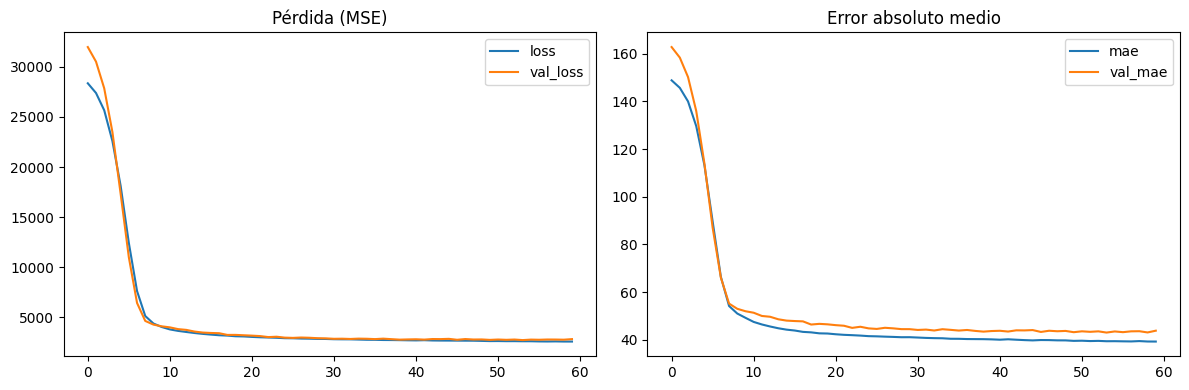

In [22]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida (MSE)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.title("Error absoluto medio")
plt.legend()

plt.tight_layout()
plt.show()


Se observa una disminución rápida del error tanto en entrenamiento como en validación durante las primeras épocas, lo que indica que el modelo aprende de manera eficiente las relaciones presentes en los datos.

Posteriormente, las curvas tienden a estabilizarse, evidenciando un proceso de convergencia. Además, la cercanía entre las curvas de entrenamiento y validación sugiere que el modelo no presenta un sobreajuste significativo, manteniendo una buena capacidad de generalización.

En particular, el error absoluto medio (MAE) en validación se mantiene en torno a 44, mientras que en entrenamiento es ligeramente menor, lo cual es esperable. En conjunto, el comportamiento de las curvas indica que la arquitectura seleccionada logra un equilibrio adecuado entre aprendizaje y generalización.

## 11. Comparar valores reales vs predichos


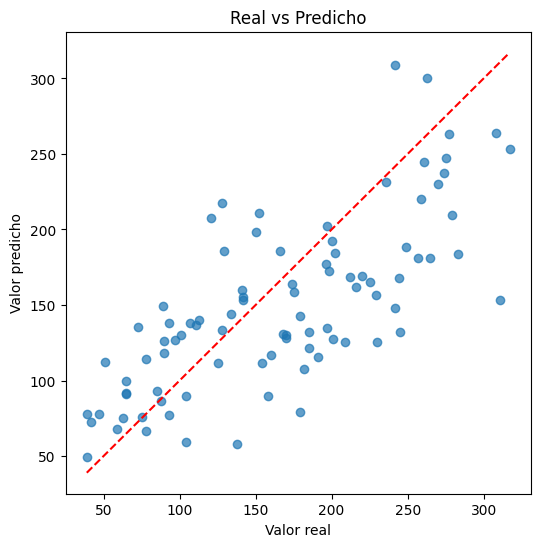

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.7)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs Predicho")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.show()


Al comparar ambos modelos, se observa que el modelo optimizado presenta una mejor alineación de los puntos respecto a la diagonal ideal, lo que indica una mayor precisión en las predicciones.

En general, se aprecia una reducción en la dispersión de los puntos en torno a la diagonal, lo que refleja una disminución del error promedio, consistente con la mejora observada en el MAE.

Sin embargo, aún se observan desviaciones en algunos rangos de valores, particularmente en valores más altos, lo que sugiere que el modelo no captura completamente toda la variabilidad de los datos.

En conjunto, tanto las métricas como la representación visual confirman una mejora en el desempeño del modelo tras el ajuste de hiperparámetros, logrando una mejor aproximación a los valores reales sin evidencias claras de sobreajuste.

## 12. Probar algunas predicciones


In [24]:
for i in range(5):
    print(f"Real: {y_val[i]:.2f} | Predicho: {y_pred[i]:.2f}")


Real: 230.00 | Predicho: 125.52
Real: 93.00 | Predicho: 77.51
Real: 225.00 | Predicho: 165.18
Real: 242.00 | Predicho: 308.97
Real: 249.00 | Predicho: 188.66


## Conclusión general

El modelo desarrollado logra capturar la tendencia general de los datos, aproximándose en varios casos a los valores reales. Se observan predicciones con errores relativamente bajos, lo que indica una capacidad adecuada de aprendizaje en ciertos rangos.

No obstante, también se identifican casos con errores elevados, donde el modelo sobreestima o subestima significativamente los valores reales. Esto evidencia que, si bien el modelo no presenta un sesgo sistemático claro, sí existe una variabilidad en su precisión dependiendo del rango de los datos.

Al comparar el modelo inicial con la versión ajustada, se observa una mejora en las métricas de desempeño, particularmente en el MAE, lo que indica una reducción del error promedio. Esta mejora también se refleja visualmente en una mayor alineación entre valores reales y predichos.

Las curvas de entrenamiento muestran una disminución consistente del error tanto en entrenamiento como en validación, sin evidencias claras de sobreajuste, lo que sugiere un proceso de aprendizaje adecuado.

En términos generales, el modelo presenta un desempeño aceptable para el problema planteado, aunque aún existe margen de mejora mediante un ajuste más fino de hiperparámetros, como se explorará mediante técnicas de búsqueda automática.